dev notes: The run_jobs function does not handle NaN data (case of sentinel-1) >>this can be solved by looking at the job json file the pixel stats are 0<<


and no item in the collection (case of sentinel-2) 

In [ ]:
import openeo, json, os, re, time 
import shutil
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
from eoapi_preprocessor import EOAPIPreprocessor
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()


True

In [ ]:
# Empty the sent1 and sent2 folders before running the rest of the notebook
for folder_name in ["sent1", "sent2"]:
    folder_path = Path(folder_name)
    if folder_path.exists():
        shutil.rmtree(folder_path)
    folder_path.mkdir(parents=True, exist_ok=True)
    print(f"Emptied '{folder_name}/'")

#Function to run jobs
MAX_CONCURRENT_JOBS = 3  # adjust to match what your account actually allows

def run_jobs(job_specs, max_concurrent=MAX_CONCURRENT_JOBS, initial_interval=10, max_interval=60):
    """
    Create, start, and wait for a list of batch jobs, without exceeding
    `max_concurrent` jobs running/queued on the backend at the same time.

    job_specs: list of (cube, create_job_kwargs) tuples.
    Returns a list of finished BatchJob objects, in the same order as job_specs.
    """
    jobs = [None] * len(job_specs)
    pending_indices = list(range(len(job_specs)))
    active = []  # list of (index, job)
    interval = initial_interval

    while pending_indices or active:
        while pending_indices and len(active) < max_concurrent:
            idx = pending_indices.pop(0)
            cube, kwargs = job_specs[idx]
            job = cube.create_job(**kwargs)
            job.start()
            jobs[idx] = job
            active.append((idx, job))
            print(f"Started job '{job.job_id}' ({kwargs.get('title')})")

        # Poll active jobs
        still_active = []
        for idx, job in active:
            status = job.status()
            print(f"Job '{job.job_id}': {status}")
            if status == "finished":
                continue
            elif status in ("error", "canceled"):
                raise RuntimeError(f"Job '{job.job_id}' did not finish successfully (status: {status})")
            else:
                still_active.append((idx, job))
        active = still_active

        if active or pending_indices:
            time.sleep(interval)
            interval = min(interval * 1.5, max_interval)

    return jobs

#Function to extract date and time
def extract_timestamp_str(metadata: dict) -> str:
    derived = [
        link["href"] for link in metadata.get("links", [])
        if link.get("rel") == "derived_from"
    ]
    timestamps = set()
    for product_id in derived:
        filename = os.path.basename(product_id)
        match = re.search(r"\d{8}T\d{6}", filename)
        if not match:
            raise ValueError(f"No timestamp found in: {filename}")
        timestamps.add(datetime.strptime(match.group(), "%Y%m%dT%H%M%S"))
    return ", ".join(sorted(t.strftime("%Y-%m-%d %H:%M:%S UTC") for t in timestamps))

Emptied 'sent1/'
Emptied 'sent2/'


## openEO API connection
This part of the code is directly taken from the copernicus dataspace ecosystem guide. 

For more information : https://documentation.dataspace.copernicus.eu/notebook-samples/sentinelhub/introduction_to_SH_APIs.html

In [152]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu")
connection.authenticate_oidc_client_credentials()

<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

### Defining the area of interest

In [146]:
aoi_coords_wgs84 = [56.116256,26.703576,56.587404,26.948675]
west, south, east, north = aoi_coords_wgs84

### User defined search parameters

In [145]:
StartDay = input('Enter start date (yyyy-mm-dd) :') 
StartTime = input('Enter start and time (hh:mm:ss) :') 
EndDay = input('Enter end date (yyyy-mm-dd) :') 

## Sentinel-2 processing

In [147]:
s2_image = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent={"west": west, "south": south, "east": east, "north": north},
    temporal_extent=[f"{StartDay}T{StartTime}Z", f"{EndDay}T23:59:59Z"],
    bands=["B04", "B03", "B02"]
)

s2_image = s2_image.min_time()
result_s2 = s2_image.save_result(format = "GTiff")

## Sentinel-1 processing

In [148]:
s1_image_original = connection.load_collection(
    "SENTINEL1_GRD",
    spatial_extent={"west": west, "south": south, "east": east, "north": north},
    temporal_extent=[f"{StartDay}T{StartTime}Z", f"{EndDay}T23:59:59Z"],
    bands=["VV"]
)
s1_image_original = s1_image_original.min_time()
s1_image = s1_image_original.sar_backscatter(coefficient="sigma0-ellipsoid")

## Run jobs

In [151]:
NON_TERMINAL_STATUSES = {"created", "queued", "running"}

for job_meta in connection.list_jobs():
    if job_meta.get("status") in NON_TERMINAL_STATUSES:
        job = connection.job(job_meta["id"])
        print(f"Cancelling leftover job '{job_meta['id']}' (status: {job_meta['status']})")
        try:
            job.stop()
        except Exception as e:
            print(f"  Could not stop job: {e}")

Cancelling leftover job 'j-2608051551114189aa24855c69999a7e' (status: created)
Cancelling leftover job 'j-26080515510741d4b933bf490d2ff161' (status: queued)
Cancelling leftover job 'j-260805145955488ebbe5cd2ab5610c5a' (status: created)
Cancelling leftover job 'j-2608051456184632b60718bd597440c7' (status: created)
Cancelling leftover job 'j-2608051455594482b354612521e60659' (status: created)
Cancelling leftover job 'j-260805124844474d8e8b249fbd6434aa' (status: created)
Cancelling leftover job 'j-2608051246314311ac20eadfe2b4d0dc' (status: created)
Cancelling leftover job 'j-26080512420644ebbec3a4c3c7e05802' (status: created)
Cancelling leftover job 'j-260731144928411aa9927edf5bcf83ff' (status: created)


In [ ]:
job_s2, job_s1 = run_jobs([ (result_s2, dict(title="Sentinel-2_image")),
                            (s1_image, dict(out_format="GTIFF", title="Sentinel-1_image")),],
                        initial_interval=30)

# Download results once both jobs have finished
job_s2.get_results().download_files("sent2")
job_s1.get_results().download_files("./sent1")

Started job 'j-2608051551314321adf0ada871d4fc0e' (Sentinel-2_image)
Started job 'j-260805155136410d9334df8427d25a6b' (Sentinel1_Processed_TIFF)
Job 'j-2608051551314321adf0ada871d4fc0e': queued
Job 'j-260805155136410d9334df8427d25a6b': queued
Job 'j-2608051551314321adf0ada871d4fc0e': queued
Job 'j-260805155136410d9334df8427d25a6b': queued
Job 'j-2608051551314321adf0ada871d4fc0e': queued
Job 'j-260805155136410d9334df8427d25a6b': queued
Job 'j-2608051551314321adf0ada871d4fc0e': running
Job 'j-260805155136410d9334df8427d25a6b': running
Job 'j-2608051551314321adf0ada871d4fc0e': running
Job 'j-260805155136410d9334df8427d25a6b': running
Job 'j-2608051551314321adf0ada871d4fc0e': running
Job 'j-260805155136410d9334df8427d25a6b': running
Job 'j-2608051551314321adf0ada871d4fc0e': finished
Job 'j-260805155136410d9334df8427d25a6b': running
Job 'j-260805155136410d9334df8427d25a6b': finished


[WindowsPath('sent1/openEO.tif'), WindowsPath('sent1/job-results.json')]

## Show outputs

✅ EO API image converted to dB and saved as ./sent1/Sentinel1_converted_dB.tif


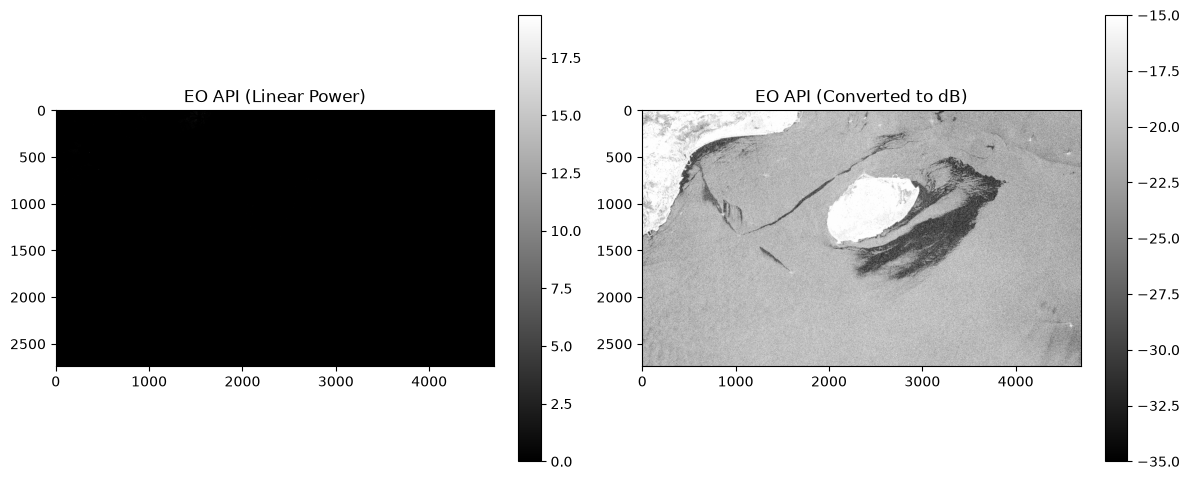

In [ ]:
# File paths
eoapi_file = "./sent1/openEO.tif"       # EO API original
eoapi_db_file = "./sent1/Sentinel1_converted_dB.tif"  # output

# Initialize preprocessor
preprocessor = EOAPIPreprocessor(eoapi_file, eoapi_db_file)

# Convert EO API image to dB
preprocessor.convert_to_db()

## Extract date and timestamps

In [10]:
with open("./sent2/job-results.json") as f:
    metadata_s2 = json.load(f)

with open("./sent1/job-results.json") as f:
    metadata_s1 = json.load(f)

timestamp_s2 = extract_timestamp_str(metadata_s2)
timestamp_s1 = extract_timestamp_str(metadata_s1)

print("S2:", timestamp_s2)
print("S1:", timestamp_s1)

S2: 2026-07-21 06:46:29 UTC
S1: 2026-07-21 14:16:27 UTC, 2026-07-23 02:14:08 UTC


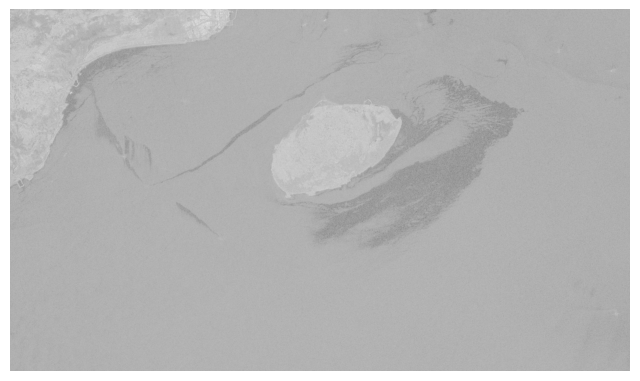

Saved sent1\Sentinel1_converted_dB.png


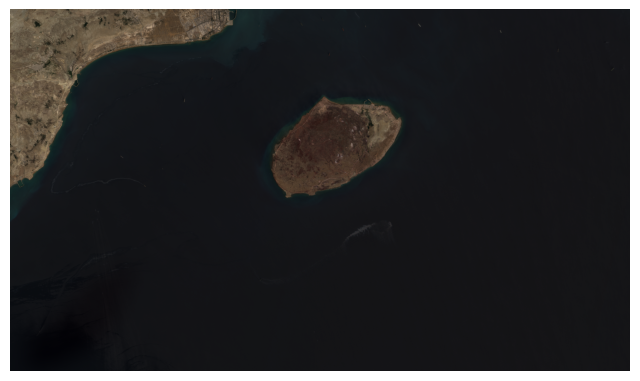

Saved sent2\openEO.png


In [ ]:
for folder in ["sent1", "sent2"]:
    for tif_path in Path(folder).glob("*.tif"):
        with rasterio.open(tif_path) as src:
            img = src.read()

        if img.shape[0] == 1:
            img, cmap = img[0], "gray"
        else:
            img, cmap = img[:3].transpose(1, 2, 0), None

        img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img))

        plt.figure(figsize=(8, 8))
        plt.imshow(img, cmap=cmap)
        plt.axis("off")
        png_path = tif_path.with_suffix(".png")
        plt.savefig(png_path, bbox_inches="tight", pad_inches=0, transparent=True)
        plt.show()
        print(f"Saved {png_path}")

## PDF report generator

In [ ]:
import io
from PIL import Image as PILImage
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, HRFlowable
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import inch, cm
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT

# PNG previews generated earlier in the notebook (see "Show outputs" section)
s1output = "./sent1/Sentinel1_converted_dB.png"
s2output = "./sent2/openEO.png"

PAGE_WIDTH, PAGE_HEIGHT = A4

DARK = colors.HexColor("#004F59")
LIGHT = colors.HexColor("#EAF5F5")
GREY = colors.HexColor("#667085")
BORDER = colors.HexColor("#D8E2E7")
TEXT = colors.HexColor("#1F2937")

# ── Paragraph styles ────────────────────────────────────────────────
base_styles = getSampleStyleSheet()

style_body = ParagraphStyle(
    "OsaBody",
    parent=base_styles["Normal"],
    fontName="Helvetica",
    fontSize=10,
    leading=15,
    textColor=TEXT,
    spaceAfter=6,
)

style_caption = ParagraphStyle(
    "OsaCaption",
    parent=base_styles["Normal"],
    fontName="Helvetica-Oblique",
    fontSize=9,
    leading=12,
    textColor=GREY,
    alignment=TA_CENTER,
    spaceBefore=4,
    spaceAfter=10,
)

style_section = ParagraphStyle(
    "OsaSection",
    parent=base_styles["Normal"],
    fontName="Helvetica-Bold",
    fontSize=16,
    leading=16,
    textColor=TEXT,
    spaceBefore=12,
    spaceAfter=8,
)

# ── (header + footer) ───────────────────────────────────────
REPORT_TITLE = "Oil Spill Analysis Report"
pageinfo = "OSA report"

def draw_header(canvas, doc):
    canvas.saveState()
    canvas.setFont("Helvetica-Bold", 20)
    canvas.setFillColor(DARK)
    canvas.drawString(
        doc.leftMargin,
        PAGE_HEIGHT-0.85*inch,
        REPORT_TITLE
    )
    canvas.setStrokeColor(LIGHT)
    canvas.setLineWidth(1)
    canvas.line(
        doc.leftMargin,
        PAGE_HEIGHT-0.95*inch,
        PAGE_WIDTH-doc.rightMargin,
        PAGE_HEIGHT-0.95*inch
    )
    canvas.drawString(inch, 0.75 * inch, "Page %d | %s" % (doc.page, pageinfo))    
    canvas.restoreState()

def draw_later_pages(canvas, doc):
    canvas.saveState()
    canvas.setFillColor(GREY)
    canvas.setFont("Helvetica", 12)
    canvas.drawString(inch, 0.55 * inch, pageinfo)
    canvas.drawString(inch, 0.75 * inch, "Page %d | %s" % (doc.page, pageinfo))
    canvas.restoreState()


# ── Build the PDF ──────────────────────────────────────────────────────────
def go():
    # timestamp_s1 / timestamp_s2 come from the "Extract date and timestamps" section
    # and look like "YYYY-MM-DD HH:MM:SS UTC"
    S1day  = timestamp_s1[:10]
    S1time = timestamp_s1[11:19]
    S2day  = timestamp_s2[:10]
    S2time = timestamp_s2[11:19]

    def _safe(ts):
        return ts.replace("-", "").replace(":", "").replace(" ", "_")

    filename = f"OSA_S1_{_safe(S1day+'_'+S1time)}_S2_{_safe(S2day+'_'+S2time)}.pdf"

    doc = SimpleDocTemplate(
        filename,
        pagesize=A4,
        leftMargin=inch,
        rightMargin=inch,
        topMargin=1.1 * inch,   # room for the header band
        bottomMargin=0.9 * inch,
    )

    usable_width  = PAGE_WIDTH - 2 * inch
    usable_height = PAGE_HEIGHT * 0.45          # cap at 45 % of page height

    story = []

    # ── Section: Sentinel-1 SAR Image ───────────────────────────────────────
    story.append(Paragraph("Sentinel-1 SAR Backscatter", style_section))
    story.append(HRFlowable(width="100%", thickness=1, color=LIGHT, spaceAfter=10))

    s1_image = Image(s1output, width=usable_width, height=usable_height)
    s1_image.hAlign = "CENTER"
    story.append(s1_image)

    s1_caption_text = (
        f"Figure 1 — Sentinel-1 SAR (VV, dB) image acquired on {S1day} at {S1time} UTC. "
        "Potential oil spill extent is visible as dark, low-backscatter patches on the water surface."
    )
    story.append(Paragraph(s1_caption_text, style_caption))

    # ── Section: Sentinel-2 Optical Image ───────────────────────────────────
    story.append(Spacer(1, 0.1 * inch))
    story.append(Paragraph("Sentinel-2 RGB Composite", style_section))
    story.append(HRFlowable(width="100%", thickness=1, color=LIGHT, spaceAfter=10))

    s2_image = Image(s2output, width=usable_width, height=usable_height)
    s2_image.hAlign = "CENTER"
    story.append(s2_image)

    s2_caption_text = (
        f"Figure 2 — Sentinel-2 true-colour composite acquired on {S2day} at {S2time} UTC. "
        "Potential oil spill extent is visible as dark, low-reflectance patches on the water surface."
    )
    story.append(Paragraph(s2_caption_text, style_caption))

    # ── Section: Acquisition Metadata ─────────────────────────────────────────
    story.append(Spacer(1, 0.2 * inch))
    story.append(Paragraph("Acquisition Metadata", style_section))
    story.append(HRFlowable(width="100%", thickness=1, color=LIGHT, spaceAfter=10))

    table_data = [
        ["Parameter", "Sentinel-1 (SAR)", "Sentinel-2 (Optical)"],
        ["Acquisition Date", S1day, S2day],
        ["Acquisition Time (UTC)", S1time, S2time],
    ]

    col_widths = [usable_width * 0.38, usable_width * 0.31, usable_width * 0.31]
    tbl = Table(table_data, colWidths=col_widths, repeatRows=1)
    tbl.setStyle(TableStyle([
        # Header row
        ("BACKGROUND",   (0, 0), (-1, 0), DARK),
        ("TEXTCOLOR",    (0, 0), (-1, 0), LIGHT),
        ("FONTNAME",     (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTSIZE",     (0, 0), (-1, 0), 9),
        ("ALIGN",        (0, 0), (-1, 0), "CENTER"),
        # Data rows alternating background
        ("BACKGROUND",   (0, 1), (-1, 1), BORDER),
        ("BACKGROUND",   (0, 2), (-1, 2), LIGHT),
        # General
        ("FONTNAME",     (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE",     (0, 1), (-1, -1), 9),
        ("TEXTCOLOR",    (0, 1), (-1, -1), DARK),
        ("ALIGN",        (1, 1), (-1, -1), "CENTER"),
        ("VALIGN",       (0, 0), (-1, -1), "MIDDLE"),
        ("TOPPADDING",   (0, 0), (-1, -1), 6),
        ("BOTTOMPADDING",(0, 0), (-1, -1), 6),
        ("GRID",         (0, 0), (-1, -1), 0.5, colors.HexColor("#D1D5DB")),
    ]))
    story.append(tbl)

    # ── Section: Analysis Note ────────────────────────────────────────────────
    story.append(Spacer(1, 0.2 * inch))
    story.append(Paragraph("Observation Notes", style_section))
    story.append(HRFlowable(width="100%", thickness=1, color=LIGHT, spaceAfter=8))

    note = (
        f"The Sentinel-1 SAR image acquired on <b>{S1day}</b> at <b>{S1time} UTC</b> was used "
        "for initial spill detection based on backscatter anomalies. "
        f"The Sentinel-2 optical image acquired on <b>{S2day}</b> at <b>{S2time} UTC</b> "
        "was used to visually confirm the extent of the potential spill."
    )
    story.append(Paragraph(note, style_body))

    doc.build(story, onFirstPage=draw_header, onLaterPages=draw_later_pages)
    print(f"PDF saved: {filename}")

if __name__ == "__main__":
    go()

PDF saved: S22026-07-21 0.pdf
